# Notebook 6: Keyword Extraction (TF-IDF)

This notebook covers the **Keyword Extraction** pipeline (Step 5), following Lab 3:
1. Loading the NER-tagged dataset from Notebook 5
2. Building a TF-IDF vectorizer over `clean_text` (as set up in Notebook 2's cleaning log)
3. Extracting top keywords overall, **implemented from scratch** (Lab 3 Task 1, point 6 — no
   library "top features" helper, just aggregated TF-IDF scores + `argsort`)
4. Extracting top keywords per consumer perspective (Notebook 3) and per sentiment (Notebook 4)
5. Saving the fitted TF-IDF vectorizer + matrix — reused later as the **lexical retrieval**
   component of the RAG system (Step 6)


## Section 1 — Setup & Dependencies

In [1]:
!pip install scikit-learn wordcloud joblib -q


In [2]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

print('All libraries loaded successfully.')


All libraries loaded successfully.


## Section 2 — Load Data

We load the NER-tagged dataset from Notebook 5. TF-IDF runs on `clean_text` (lemmatised,
stopword-filtered tokens) — this is the column Notebook 2 explicitly reserved for
"BERTopic and TF-IDF", separate from `light_clean_text` used for VADER/RoBERTa/spaCy NER.

In [3]:
df = pd.read_csv("ner_comments.csv.gz")

print(f'Shape: {df.shape}')
print()
print('Columns:', list(df.columns))
df.head(3)


Shape: (51684, 19)

Columns: ['comment_id', 'video_id', 'title', 'author', 'published_at', 'like_count', 'text', 'light_clean_text', 'clean_text', 'word_count', 'char_count', 'lda_topic', 'topic', 'perspective', 'vader_sentiment', 'final_sentiment', 'final_sentiment_label', 'entities', 'entity_count']


,comment_id,video_id,title,author,published_at,like_count,text,light_clean_text,clean_text,word_count,char_count,lda_topic,topic,perspective,vader_sentiment,final_sentiment,final_sentiment_label,entities,entity_count
0,UgxmVVEhmGQ0ovq6tRR4AaABAg,PEY8IyB653c,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC...",@jadehannah916,2026-06-22 19:50:06+00:00,0,19:23 expiry dates have left the chat,expiry dates have left the chat,expiry date leave chat,4,22,0,-1,Outlier / Noise,0,0,Neutral,[],0
1,Ugwfz5ugRqp0yxubW9t4AaABAg,PEY8IyB653c,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC...",@jadehannah916,2026-06-22 19:46:57+00:00,0,16:34 just work at a grocery store at this point,just work at a grocery store at this point,work grocery store point,4,24,3,-1,Outlier / Noise,0,0,Neutral,[],0
2,UgwvTEiO61bpwRH3Dn14AaABAg,PEY8IyB653c,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC...",@Sevdalina-e2l,2026-06-22 11:08:51+00:00,0,19:40 this specific content made my heart blee...,this specific content made my heart bleed. Lik...,specific content heart bleed like mean empty k...,10,61,2,6,Everyday Objects & Consumption,1,1,Positive,"[('😔', 'ORG')]",1


In [4]:
df = df.dropna(subset=['clean_text']).copy()
df['clean_text'] = df['clean_text'].astype(str)
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)
print(f'Rows ready for TF-IDF: {len(df):,}')


Rows ready for TF-IDF: 51,684


## Section 3 — Build TF-IDF Vectorizer

As in Lab 3, we compare `ngram_range=(1,1)` vs `(1,2)` before choosing. Bigrams matter for this
project — phrases like "credit card" or "fast fashion" carry meaning that unigrams alone lose.

In [5]:
# ── Compare unigram-only vs unigram+bigram vocabulary size and fit time ────
for ngram_range in [(1, 1), (1, 2)]:
    start = time.time()
    vec = TfidfVectorizer(
        min_df=5,
        max_df=0.6,
        ngram_range=ngram_range,
        norm='l2',
        use_idf=True,
        smooth_idf=True,
        sublinear_tf=True
    )
    matrix = vec.fit_transform(df['clean_text'])
    elapsed = time.time() - start
    print(f'ngram_range={ngram_range}: vocab={len(vec.vocabulary_):,}, '
          f'shape={matrix.shape}, fit+transform={elapsed:.2f}s')


ngram_range=(1, 1): vocab=8,667, shape=(51684, 8667), fit+transform=4.35s
ngram_range=(1, 2): vocab=29,614, shape=(51684, 29614), fit+transform=6.85s


In [6]:
# ── Final vectorizer: unigrams + bigrams capture more meaningful project-specific phrases ──
tfidf_vectorizer = TfidfVectorizer(
    min_df=5,
    max_df=0.6,
    ngram_range=(1, 2),
    norm='l2',
    use_idf=True,
    smooth_idf=True,
    sublinear_tf=True
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df['clean_text'])
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')
print(f'Vocabulary size: {len(feature_names):,}')


TF-IDF matrix shape: (51684, 29614)
Vocabulary size: 29,614


## Section 4 — Top Keywords Overall

Implemented from scratch (Lab 3 Task 1, point 6): aggregate TF-IDF scores across all documents
per term, then `argsort` to get the top N — no library "get top features" helper used.

In [7]:
def get_top_keywords(matrix, feature_names, top_n=25, row_indices=None):
    """
    Aggregates TF-IDF scores across documents (optionally a subset given by row_indices)
    and returns the top_n (term, score) pairs, sorted descending. Implemented from scratch
    with numpy argsort rather than a library helper.
    """
    subset = matrix[row_indices] if row_indices is not None else matrix
    scores = np.asarray(subset.sum(axis=0)).flatten()
    top_indices = np.argsort(scores)[::-1][:top_n]
    return [(feature_names[i], round(float(scores[i]), 2)) for i in top_indices]

top_25_overall = get_top_keywords(tfidf_matrix, feature_names, top_n=25)
for term, score in top_25_overall:
    print(f'{term:30s} {score:.2f}')


like                           1059.49
buy                            813.70
bag                            720.38
love                           658.87
use                            586.82
video                          586.64
stuff                          561.67
product                        514.14
go                             512.30
year                           496.27
good                           467.56
laugh                          454.64
girl                           417.94
make                           412.14
money                          408.36
thank                          402.94
loud                           394.23
influencer                     391.09
work                           385.97
purse                          384.77
new                            383.40
laugh loud                     383.08
content                        363.30
life                           361.41
ice                            341.96


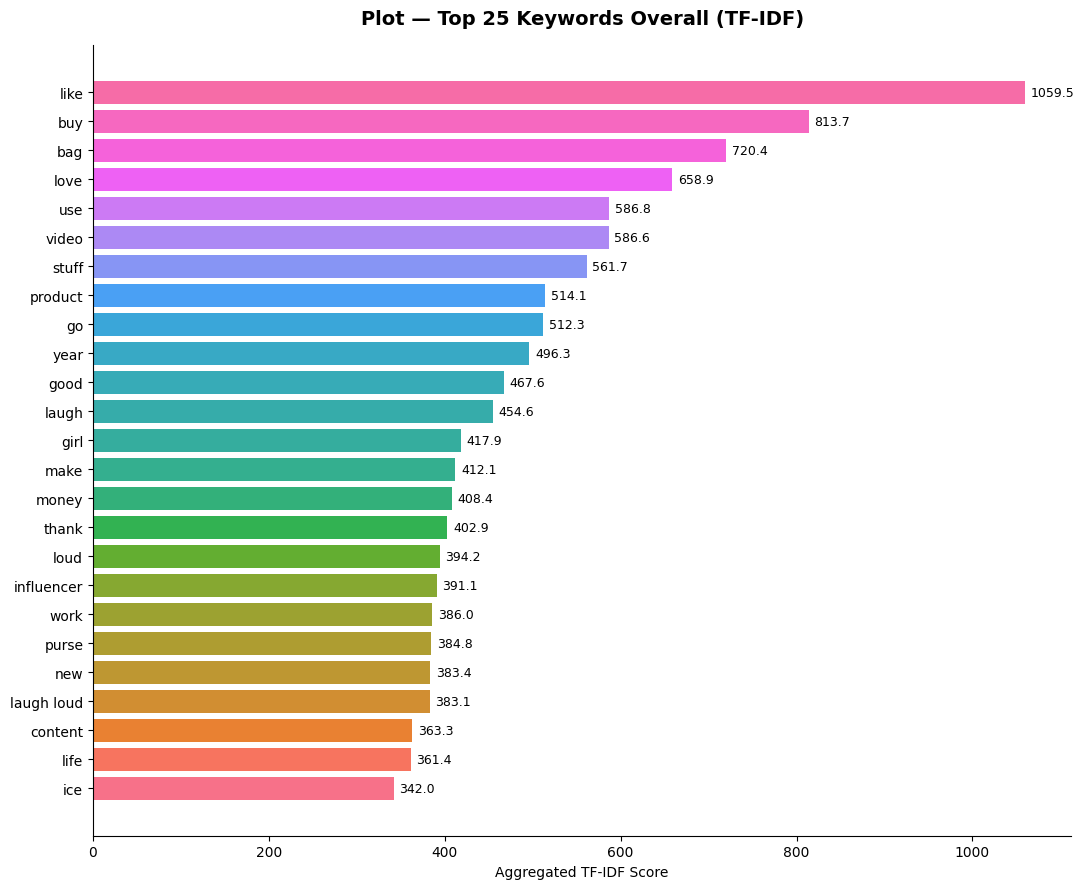

In [9]:
import os

# ── Plot: Top 25 keywords overall ───────────────────────────────────────
terms, scores = zip(*top_25_overall)

fig, ax = plt.subplots(figsize=(11, 9))
bars = ax.barh(terms[::-1], scores[::-1], color=sns.color_palette('husl', 25))
ax.bar_label(bars, fmt='%.1f', padding=4, fontsize=9)
ax.set_title('Plot — Top 25 Keywords Overall (TF-IDF)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Aggregated TF-IDF Score')
plt.tight_layout()
os.makedirs('eda', exist_ok=True)  # Create 'eda' directory if it doesn't exist
plt.savefig('eda/keyword_01_top25_overall.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 5 — Keywords per Consumer Perspective

Reuses the same fitted vocabulary and `tfidf_matrix` — no need to refit per group, just subset
the matrix rows by perspective. This is the key business insight: what distinguishes each
perspective's language from the others.

In [10]:
perspective_keywords = {}

for perspective in df['perspective'].unique():
    row_indices = df.index[df['perspective'] == perspective].to_numpy()
    perspective_keywords[perspective] = get_top_keywords(
        tfidf_matrix, feature_names, top_n=10, row_indices=row_indices
    )

for perspective, keywords in perspective_keywords.items():
    terms = ', '.join([t for t, _ in keywords])
    print(f'{perspective}\n  {terms}\n')


Outlier / Noise
  like, bag, buy, video, stuff, love, use, product, go, purse

Everyday Objects & Consumption
  ice, bag, jar, use, like, buy, fridge, video, love, restock

Society, Economy & Power Systems
  vegan, friend, vegan product, product, bring, vegan friend, bathroom, natural, rating, girl

Other
  like, love, buy, laugh, girl, loud, go, tiktok, laugh loud, hannah

Abstract / Meme / Philosophical
  nail, plastic, tap, recycle, waste, fingernail, landfill, plastic waste, nail tap, long

Digital Media & Pop Culture
  glow, cat, love, girl, kitty, like, glow up, up, meow, love cat

Consumerism & Material Culture
  blush, asmr, social, social medium, medium, girl, like, organize, bully, blush collection

Beauty & Self-Presentation
  collect, consumerism, collection, like, slavery, buy, decor, year, fall, love

Social Life & Identity
  razor, book, read, overconsumption, buy, library, lecture, like, link, professor

Health, Routine & Physical Behavior
  influencer, makeup, blood, t

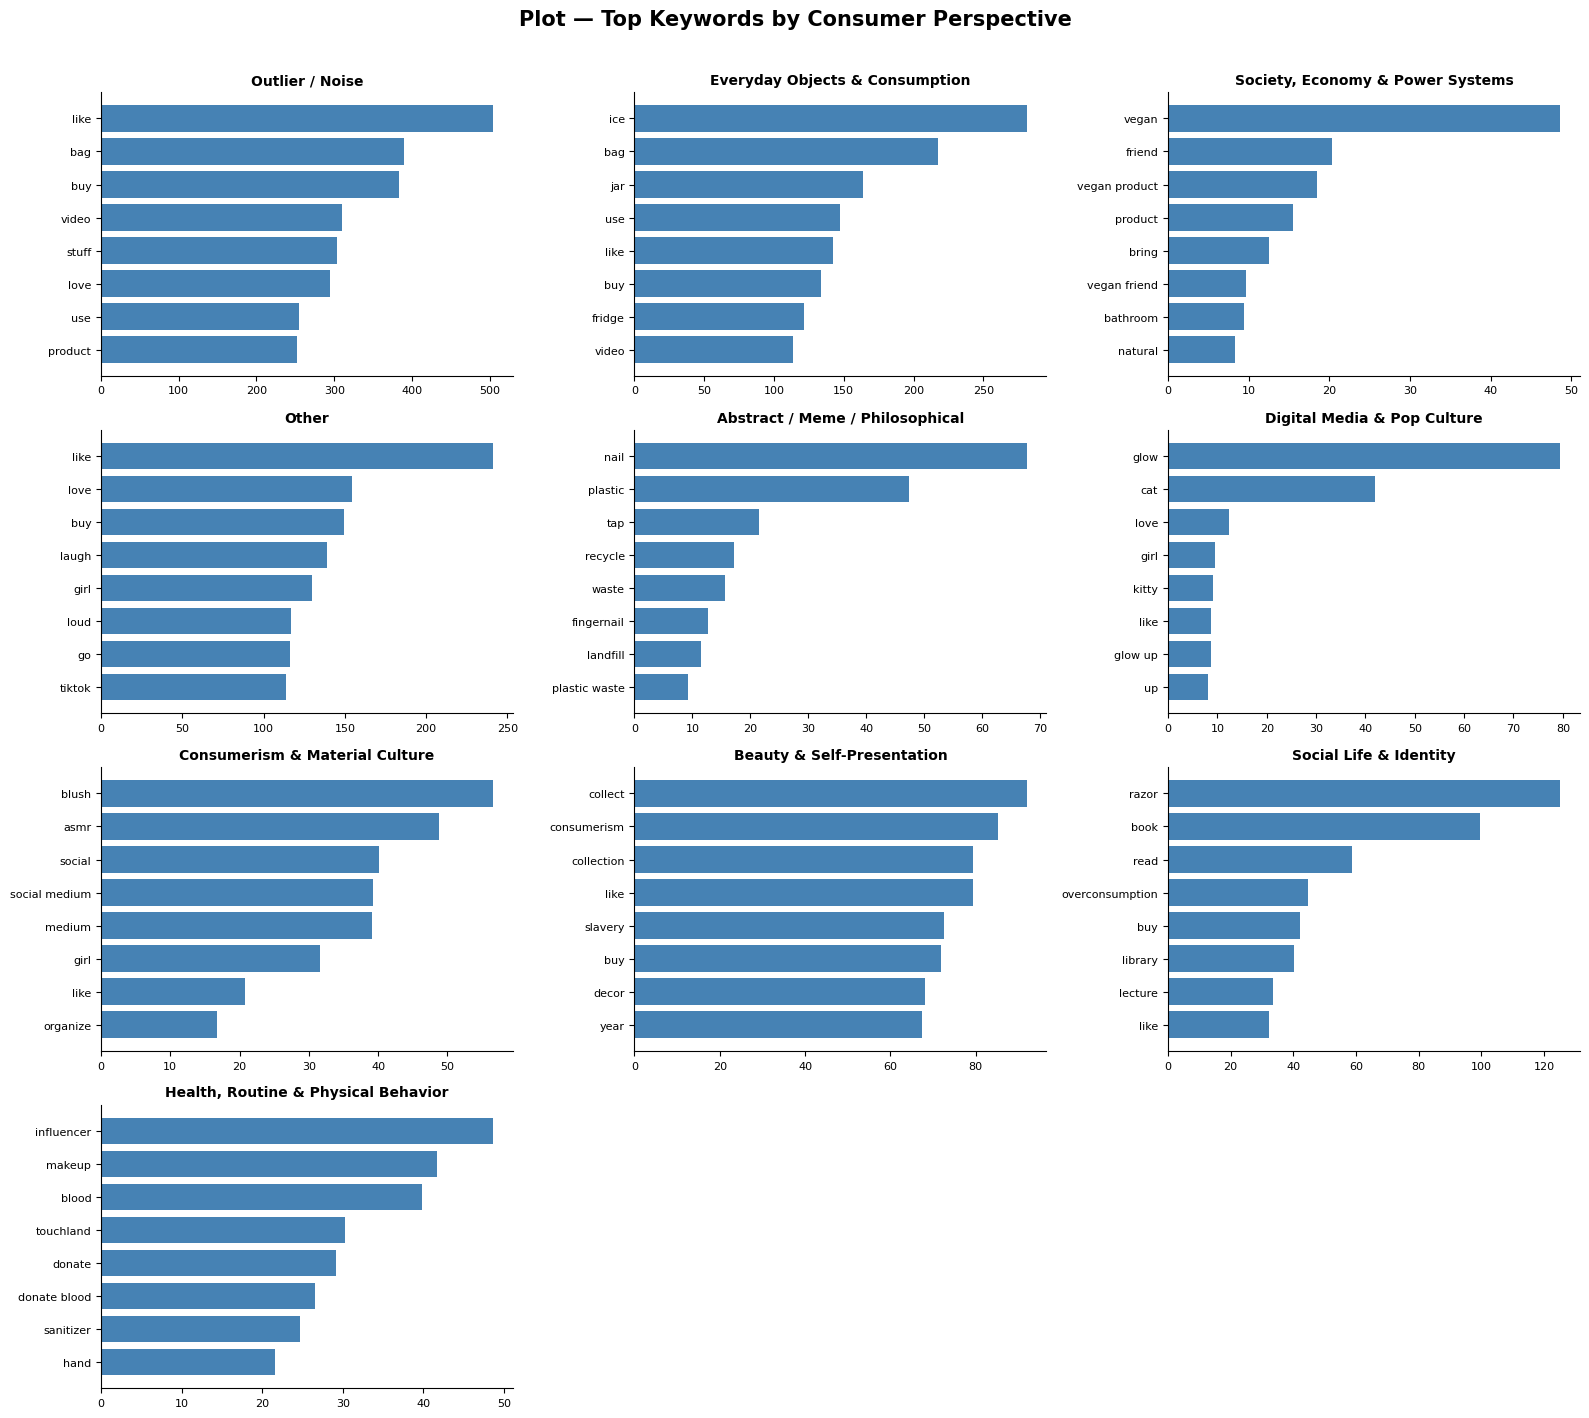

In [11]:
# ── Plot: Top 8 keywords for each perspective, grid of subplots ────────────
n_perspectives = len(perspective_keywords)
n_cols = 3
n_rows = int(np.ceil(n_perspectives / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for ax, (perspective, keywords) in zip(axes, perspective_keywords.items()):
    top8 = keywords[:8]
    terms, scores = zip(*top8)
    ax.barh(terms[::-1], scores[::-1], color='steelblue')
    ax.set_title(perspective[:35], fontsize=10, fontweight='bold')
    ax.tick_params(labelsize=8)

for ax in axes[len(perspective_keywords):]:
    ax.axis('off')

plt.suptitle('Plot — Top Keywords by Consumer Perspective', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda/keyword_02_keywords_by_perspective.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 6 — Keywords per Sentiment

Same subsetting approach, split by `final_sentiment_label` from Notebook 4.

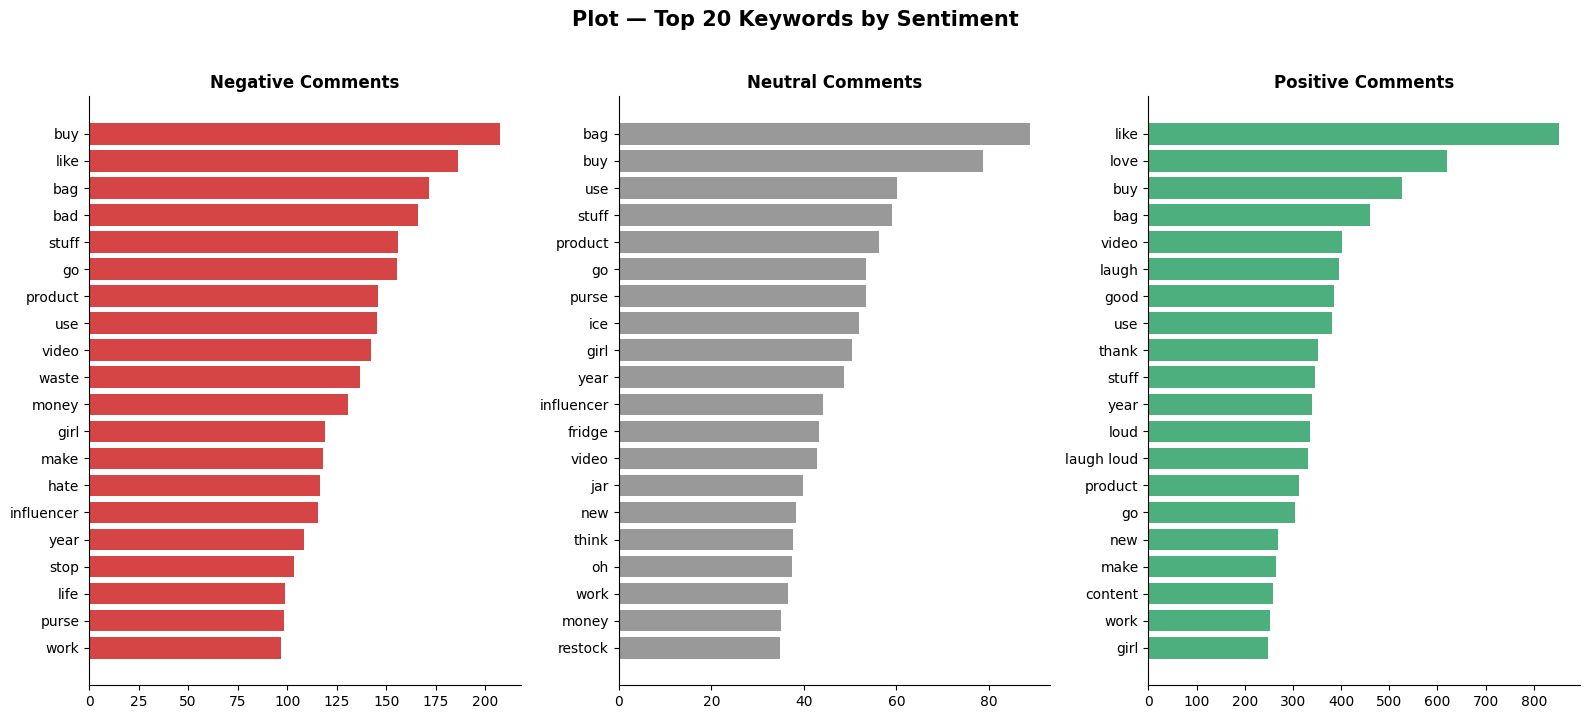

In [12]:
sentiment_keywords = {}

for sentiment in ['Negative', 'Neutral', 'Positive']:
    row_indices = df.index[df['final_sentiment_label'] == sentiment].to_numpy()
    if len(row_indices) == 0:
        continue
    sentiment_keywords[sentiment] = get_top_keywords(
        tfidf_matrix, feature_names, top_n=20, row_indices=row_indices
    )

fig, axes = plt.subplots(1, len(sentiment_keywords), figsize=(16, 7))
colors = {'Negative': '#d64545', 'Neutral': '#999999', 'Positive': '#4caf7d'}

for ax, (sentiment, keywords) in zip(axes, sentiment_keywords.items()):
    terms, scores = zip(*keywords)
    ax.barh(terms[::-1], scores[::-1], color=colors[sentiment])
    ax.set_title(f'{sentiment} Comments', fontsize=12, fontweight='bold')

plt.suptitle('Plot — Top 20 Keywords by Sentiment', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda/keyword_03_keywords_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()


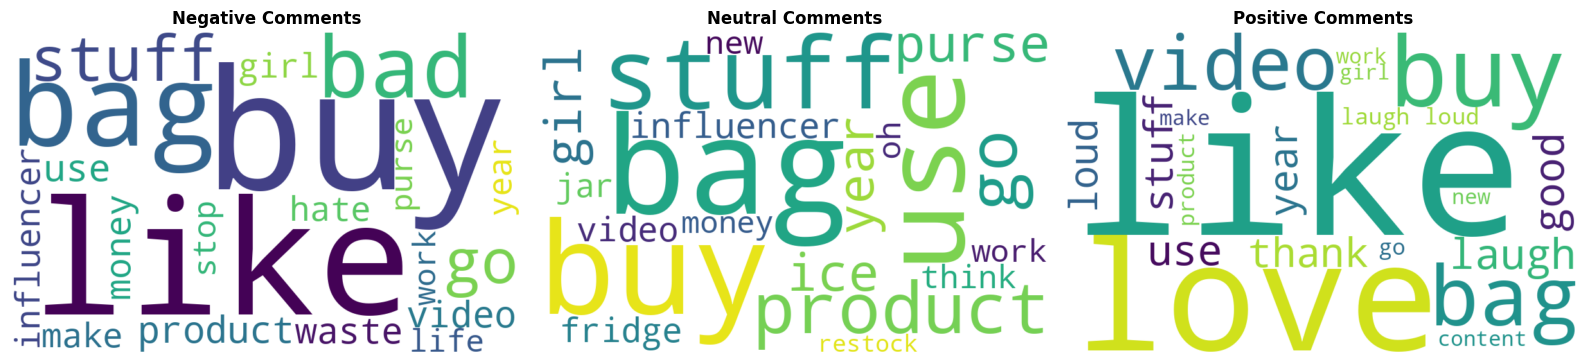

In [13]:
# ── Sentiment keyword word clouds ───────────────────────────────────────
fig, axes = plt.subplots(1, len(sentiment_keywords), figsize=(16, 6))

for ax, (sentiment, keywords) in zip(axes, sentiment_keywords.items()):
    freq_dict = dict(keywords)
    wc = WordCloud(width=800, height=500, background_color='white').generate_from_frequencies(freq_dict)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{sentiment} Comments', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('eda/keyword_04_sentiment_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 7 — Save Results

Three things are exported:
- `keywords_overall.csv` / `keywords_by_perspective.csv` / `keywords_by_sentiment.csv` — for the dashboard
- `tfidf_vectorizer.pkl` + `tfidf_matrix.pkl` — the fitted vectorizer and matrix, reused as the
  **lexical retrieval** option in the RAG system (Step 6), alongside semantic (embedding) retrieval

In [14]:
# Overall keywords
pd.DataFrame(top_25_overall, columns=['term', 'tfidf_score']).to_csv('keywords_overall.csv', index=False)

# Per-perspective keywords
perspective_rows = [
    {'perspective': p, 'term': t, 'tfidf_score': s}
    for p, kws in perspective_keywords.items() for t, s in kws
]
pd.DataFrame(perspective_rows).to_csv('keywords_by_perspective.csv', index=False)

# Per-sentiment keywords
sentiment_rows = [
    {'sentiment': sent, 'term': t, 'tfidf_score': s}
    for sent, kws in sentiment_keywords.items() for t, s in kws
]
pd.DataFrame(sentiment_rows).to_csv('keywords_by_sentiment.csv', index=False)

print('Saved keywords_overall.csv, keywords_by_perspective.csv, keywords_by_sentiment.csv')


Saved keywords_overall.csv, keywords_by_perspective.csv, keywords_by_sentiment.csv


In [15]:
# Save the fitted vectorizer and matrix for reuse as the RAG lexical retriever
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')
joblib.dump(tfidf_matrix, 'tfidf_matrix.pkl')

# Save the row order (comment_id) so the matrix rows can be mapped back to comments later
df[['comment_id']].reset_index(drop=True).to_csv('tfidf_row_index.csv', index=False)

print('Saved tfidf_vectorizer.pkl, tfidf_matrix.pkl, tfidf_row_index.csv')


Saved tfidf_vectorizer.pkl, tfidf_matrix.pkl, tfidf_row_index.csv


## Summary

TF-IDF (unigrams + bigrams, `min_df=5`, `max_df=0.6`) was fit over `clean_text`. Top keywords
were extracted from scratch by aggregating TF-IDF scores and sorting with `argsort`, at three
levels: overall, per consumer perspective, and per sentiment. The per-perspective breakdown is
the key business insight — it shows the exact vocabulary that distinguishes each discussion
block (e.g. financial-minimalist language vs. product-durability complaints vs. cynical
corporate-hypocrisy callouts), which is precisely what the project's business pitch sells to
brands.

The fitted TF-IDF vectorizer and matrix were saved for reuse as the **lexical retrieval**
component in the RAG system (Step 6), so the project doesn't have to choose between lexical and
semantic retrieval — it can support both, plus a hybrid combination, satisfying the "Retrieval
(options: metadata, semantic, lexical, hybrid)" deliverable from the project brief.

**Limitation:** TF-IDF is a bag-of-words method — it has no notion of semantic similarity (e.g.
"cheap" and "affordable" are unrelated to it), which is exactly why a semantic embedding-based
retriever is also needed for the RAG system rather than TF-IDF alone. This is discussed further
in the report's Methodology and Limitations sections.